In [3]:
import os
import yaml
import multiprocessing as mp
import time
import tools21cm as t2c
from tqdm import tqdm
import astropy.units as u
import astropy.constants as cst
import cupy as cp
import numpy as np
import itertools

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"

from scipy.interpolate import make_interp_spline

In [4]:
def parse_timesteps(timesteps_config):
    if isinstance(timesteps_config, str):
        start, end = map(int, timesteps_config.split(':'))
        return list(range(start, end))
    elif isinstance(timesteps_config, list):
        return timesteps_config
    else:
        raise ValueError("Invalid format for timesteps. Use a list or a range string (e.g., '50:60').")
        
def read_config(input_path):
    with open(input_path) as stream:
        try:
            config = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)
    return config

In [54]:
if __name__ == "__main__":
    config = read_config("input/config_SKA_multistep.yaml")
    
    #Setting the timestep list using the parse_timesteps function
    timesteps = parse_timesteps(config["timesteps"])
    
    num_times= config["num_times"]
    #num_bins = config["num_bins"]
    num_bins = 50
    
    all_bls= cp.load('baselines_all_dTgf_32.npy', mmap_mode='r')
    all_vis= cp.load('visibilities_all_dTgf.npy', mmap_mode='r')

    
    all_norms = cp.empty((len(timesteps), num_bins))
    all_norms_nonzero = cp.empty((len(timesteps), num_bins))
    
    timestep_len = len(all_bls) // num_times
    
    maxmin_norm = cp.empty((len(timesteps), 2))
    maxmin_norm_nonzero = cp.empty((len(timesteps), 2))
    start_time = time.time()
    for count, timestep in enumerate(timesteps):
        bls= all_bls[timestep * timestep_len : (timestep + 1) * timestep_len]
        vis= all_vis[timestep * timestep_len : (timestep + 1) * timestep_len]
        
        #Compute the norms and find the max and min values
        norms = cp.linalg.norm(bls, axis = 1)
        maxmin_norm[count, 0] = cp.max(norms)
        maxmin_norm[count, 1] = cp.min(norms)
        
        # Filtering baselines with zero visibility
        non_zero_indices = cp.where(vis != 0)[0]
        bls_nonzero = bls[non_zero_indices]
        # Compute the norm of the non-zero baseline vectors and find the max and min values
        norms_nonzero = cp.linalg.norm(bls_nonzero, axis=1)
        maxmin_norm_nonzero[count, 0] = cp.max(norms_nonzero)
        maxmin_norm_nonzero[count, 1] = cp.min(norms_nonzero)
    end_time = time.time()
    
    print('Time to find the max and min norms to create bin edges: ', round(end_time - start_time, 3), 's')
    print("Max and min norms: ", cp.max(maxmin_norm[:,0]), cp.min(maxmin_norm[:,1]))
    print("Max and min nonzero vis norms: ", cp.max(maxmin_norm_nonzero[:,0]), cp.min(maxmin_norm_nonzero[:,1]))
    
    bins = cp.linspace(cp.min(maxmin_norm[:,1]) - 1, cp.max(maxmin_norm[:,0]) + 1, num_bins + 1)
    bins_nonzero = cp.linspace(cp.min(maxmin_norm_nonzero[:,1]) - 1, cp.max(maxmin_norm_nonzero[:,0]) + 1, num_bins + 1)
    
    start_time = time.time()
    for count, timestep in enumerate(timesteps):
        #print('*'*50)
        #print('Timestep', timestep)
        bls= all_bls[timestep * timestep_len : (timestep + 1) * timestep_len]
        vis= all_vis[timestep * timestep_len : (timestep + 1) * timestep_len]
        
        norms = cp.linalg.norm(bls, axis = 1)
        
        # Compute histogram of the norms using the predefined bins
        hist, _ = cp.histogram(norms, bins=bins)
        
        # Filtering baselines with zero visibility
        non_zero_indices = cp.where(vis != 0)[0]
        bls_nonzero = bls[non_zero_indices]
        
        # Compute the norm of the non-zero baseline vectors
        norms_nonzero = cp.linalg.norm(bls_nonzero, axis=1)
        
        # Compute histogram of the non-zero norms using the predefined bins
        hist_nonzero, _ = cp.histogram(norms_nonzero, bins=bins_nonzero)
        
        all_norms[count] = hist
        all_norms_nonzero[count] = hist_nonzero
    end_time = time.time()
    print("Time to run the analysis: ", round(end_time - start_time, 3), 's')
    
all_norms_avg = cp.mean(all_norms, axis = 0)
all_norms_nonzero_avg = cp.mean(all_norms_nonzero, axis = 0)

Time to find the max and min norms to create bin edges:  0.927 s
Max and min norms:  73508.609375 37.486488342285156
Max and min nonzero vis norms:  8824.0732421875 37.486488342285156
Time to run the analysis:  0.962 s


Text(0.5, 1.0, 'Average Number Density Plot of Non-zero Baseline Norms')

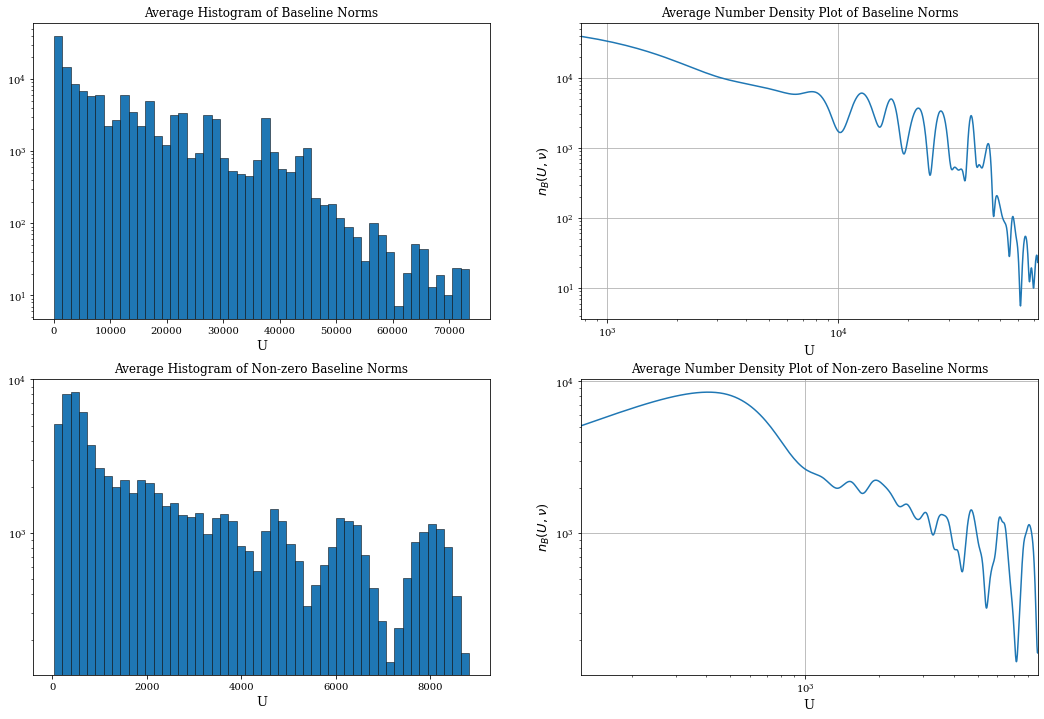

In [93]:
# Create the plot using subplots
fig, axs = plt.subplots(2, 2, figsize=(18, 12))

axs[0,0].bar(cp.asnumpy(bins[:-1]), cp.asnumpy(all_norms_avg), width=cp.asnumpy(bins[1]-bins[0]), align='edge', 
             label='All Norms', edgecolor='black', linewidth= 0.5)
axs[0,0].set_xlabel('U', fontsize= 13)
axs[0,0].set_yscale('log')
axs[0,0].set_title('Average Histogram of Baseline Norms')


axs[1,0].bar(cp.asnumpy(bins_nonzero[:-1]), cp.asnumpy(all_norms_nonzero_avg), width=cp.asnumpy(bins_nonzero[1]-bins_nonzero[0]), align='edge', 
             label='All Norms', edgecolor='black', linewidth= 0.5)
axs[1,0].set_xlabel('U', fontsize= 13)
axs[1,0].set_yscale('log')
axs[1,0].set_title('Average Histogram of Non-zero Baseline Norms')


# Compute the bin midpoints for interpolation
bin_midpoints = cp.asnumpy((bins[:-1] + bins[1:]) / 2)

# Interpolate the average histograms for all norms
spline_all_norms = make_interp_spline(bin_midpoints, cp.asnumpy(all_norms_avg), k=3)
x_smooth_all_norms = np.linspace(bin_midpoints.min(), bin_midpoints.max(), 500)
y_smooth_all_norms = spline_all_norms(x_smooth_all_norms)

axs[0,1].plot(x_smooth_all_norms, y_smooth_all_norms)
axs[0,1].set_xlabel('U', fontsize= 13)
axs[0,1].set_ylabel(r'$n_B(U, \nu$)', fontsize= 13)
axs[0,1].set_xscale('log')
axs[0,1].set_yscale('log')
axs[0,1].grid()
axs[0,1].set_xlim([x_smooth_all_norms.min(), x_smooth_all_norms.max()])
axs[0,1].set_title('Average Number Density Plot of Baseline Norms')


# Compute the bin midpoints for interpolation
bin_nonzero_midpoints = cp.asnumpy((bins_nonzero[:-1] + bins_nonzero[1:]) / 2)

# Interpolate the average histograms for non-zero norms
spline_nonzero_norms = make_interp_spline(bin_nonzero_midpoints, cp.asnumpy(all_norms_nonzero_avg), k=3)
x_smooth_nonzero_all_norms = np.linspace(bin_nonzero_midpoints.min(), bin_nonzero_midpoints.max(), 500)
y_smooth_nonzero_all_norms = spline_nonzero_norms(x_smooth_nonzero_all_norms)

axs[1,1].plot(x_smooth_nonzero_all_norms, y_smooth_nonzero_all_norms)
axs[1,1].set_xlabel('U', fontsize= 13)
axs[1,1].set_ylabel(r'$n_B(U, \nu$)', fontsize= 13)
axs[1,1].set_xscale('log')
axs[1,1].set_yscale('log')
axs[1,1].grid()
axs[1,1].set_xlim([x_smooth_nonzero_all_norms.min(), x_smooth_nonzero_all_norms.max()])
axs[1,1].set_title('Average Number Density Plot of Non-zero Baseline Norms')

In [91]:
print(bin_nonzero_midpoints[0:2])
print(bins_nonzero[0])
print(bins_nonzero[1])

[124.37235588 300.14409096]
36.486488342285156
212.25822341918945
